# Job Market Intelligence — exploration et contrôle qualité

Ce notebook accompagne le pipeline (`python -m jmi run`). Il sert à deux choses :

1. **contrôler la qualité** des données nettoyées avant de publier quoi que ce soit (valeurs manquantes, « Non précisé », villes non reconnues, précision de l'extraction de compétences) ;
2. **explorer** le marché : volumes, salaires, compétences, télétravail.

Il lit `data/processed/` et `exports/tableau/`, donc il faut avoir lancé le pipeline juste avant. Relance-le entièrement (*Kernel › Restart & Run All*) après chaque nouvelle collecte.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED, EXPORTS = ROOT / "data" / "processed", ROOT / "exports" / "tableau"

offers = pd.read_csv(PROCESSED / "offers_clean.csv", parse_dates=["published_date", "published_month"])
links = pd.read_csv(PROCESSED / "offer_skills.csv")
skills_by_role = pd.read_csv(EXPORTS / "competences_par_metier.csv")

# Style sobre : une teinte principale, grille discrète, pas de cadre inutile
BLUE, INK, MUTED, GRID = "#2a78d6", "#0b0b0b", "#898781", "#e1e0d9"
SEQ = "Blues"
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})
eur = mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f} k€")

if offers["is_demo"].eq(1).any():
    print("⚠️  JEU DE DÉMONSTRATION SYNTHÉTIQUE — aucune conclusion sur le marché réel.")
print(f"{len(offers)} offres | sources : {offers['source'].value_counts().to_dict()}")
print(f"Période : {offers['published_date'].min():%d/%m/%Y} → {offers['published_date'].max():%d/%m/%Y}")

⚠️  JEU DE DÉMONSTRATION SYNTHÉTIQUE — aucune conclusion sur le marché réel.
1196 offres | sources : {'demo': 1196}
Période : 08/04/2026 → 29/09/2026


## 1. Contrôle qualité

À regarder **avant** de construire le dashboard. Repères indicatifs : moins de 10 % de métiers « Autre », moins de 30 % de séniorité « Non précisé », moins de 10 % de villes sans région. Au-delà, il faut enrichir les règles dans `src/jmi/clean/normalize.py` ou `config/cities_fr.csv`.

In [2]:
unknown = {
    "Métier = Autre métier data": (offers["role_family"] == "Autre métier data").mean(),
    "Séniorité non précisée": (offers["seniority"] == "Non précisé").mean(),
    "Contrat non précisé": (offers["contract_type"] == "Non précisé").mean(),
    "Télétravail non précisé": (offers["remote_policy"] == "Non précisé").mean(),
    "Ville non précisée": (offers["city"] == "Non précisé").mean(),
    "Région non reconnue": (offers["region"] == "Non précisé").mean(),
    "Secteur non reconnu": (offers["sector"] == "Autre / Non précisé").mean(),
    "Sans salaire exploitable": 1 - offers["has_salary"].mean(),
    "Sans aucune compétence détectée": 1 - offers["offer_id"].isin(links["offer_id"]).mean(),
}
quality = pd.Series(unknown, name="part").to_frame()
quality["part"] = (quality["part"] * 100).round(1).astype(str) + " %"
quality

,part
Métier = Autre métier data,0.0 %
Séniorité non précisée,16.6 %
Contrat non précisé,0.0 %
Télétravail non précisé,24.8 %
Ville non précisée,2.0 %
Région non reconnue,2.8 %
Secteur non reconnu,0.0 %
Sans salaire exploitable,55.7 %
Sans aucune compétence détectée,0.0 %


Intitulés classés « Autre métier data » les plus fréquents : ce sont les candidats à une nouvelle règle dans `ROLE_RULES`.

In [3]:
offers.loc[offers["role_family"] == "Autre métier data", "title"].value_counts().head(20)

Series([], Name: count, dtype: int64)

Villes sans région : à ajouter dans `config/cities_fr.csv` si elles reviennent souvent.

In [4]:
offers.loc[(offers["region"] == "Non précisé") & (offers["city"] != "Non précisé"), "city"].value_counts().head(20)

city
Niort    10
Name: count, dtype: int64

### Vérification manuelle de l'extraction de compétences

Tirage aléatoire de 15 offres : compare les compétences détectées au texte. Note les oublis et les faux positifs, puis corrige `config/skills_dictionary.yaml`. Fais-le au moins une fois sur données réelles (objectif : plus de 90 % de détections justes).

In [5]:
sample = offers.sample(15, random_state=0)
detected = links.groupby("offer_id")["skill"].apply(lambda s: ", ".join(sorted(s)))
for row in sample.itertuples():
    print(f"■ {row.title}  [{row.role_family} / {row.seniority}]")
    print(f"  Compétences : {detected.get(row.offer_id, '—')}")
    print(f"  Texte : {str(row.description)[:260]}…\n")

■ Analyste de données  [Data Analyst / Junior]
  Compétences : Agile/Scrum, Anglais, Communication, Esprit d'analyse, Excel, KPI & reporting, Power BI, SQL, Snowflake, Tableau
  Texte : Logistique Sigma (transports et logistique) recrute un(e) Analyste de données. Vous accompagnerez nos clients dans leurs projets de transformation data. Compétences recherchées : SQL, Excel, Tableau, Power BI, reporting et KPI, communication, anglais, Snowflak…

■ Data Engineer Cloud Junior  [Data Engineer / Junior]
  Compétences : AWS, Airflow, Azure, ETL/ELT, Git, KPI & reporting, Kubernetes, Spark, dbt
  Texte : Réseau Électrique Gamma (production et distribution d'électricité et de gaz) recrute un(e) Data Engineer Cloud Junior. Vous construirez des tableaux de bord pour les équipes métier et automatiserez le reporting. Compétences recherchées : Spark, Airflow, dbt, A…

■ Data Scientist - Machine Learning  [Data Scientist / Confirmé]
  Compétences : AWS, Anglais, Deep Learning, ETL/ELT, IA générative

## 2. Volume des offres

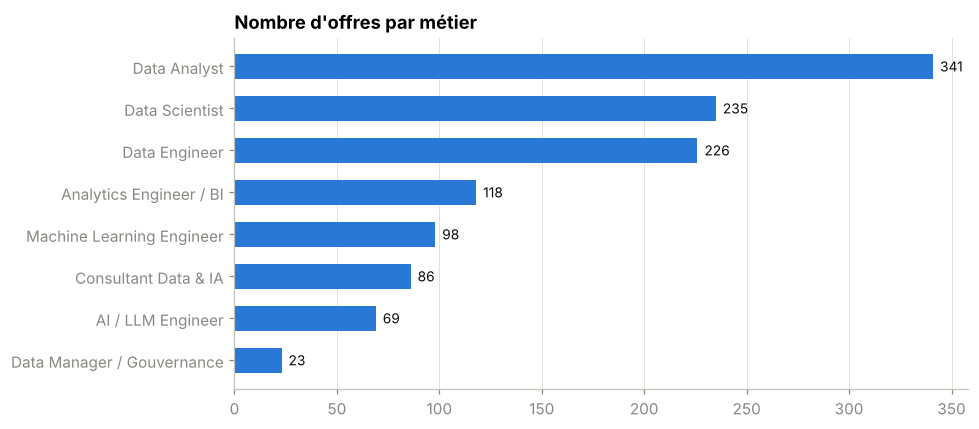

In [6]:
counts = offers["role_family"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(counts.index, counts.values, color=BLUE, height=0.6)
for y, v in enumerate(counts.values):
    ax.text(v + counts.max() * 0.01, y, f"{v}", va="center", color=INK, fontsize=9)
ax.set_title("Nombre d'offres par métier")
ax.grid(axis="y", visible=False)
plt.tight_layout()

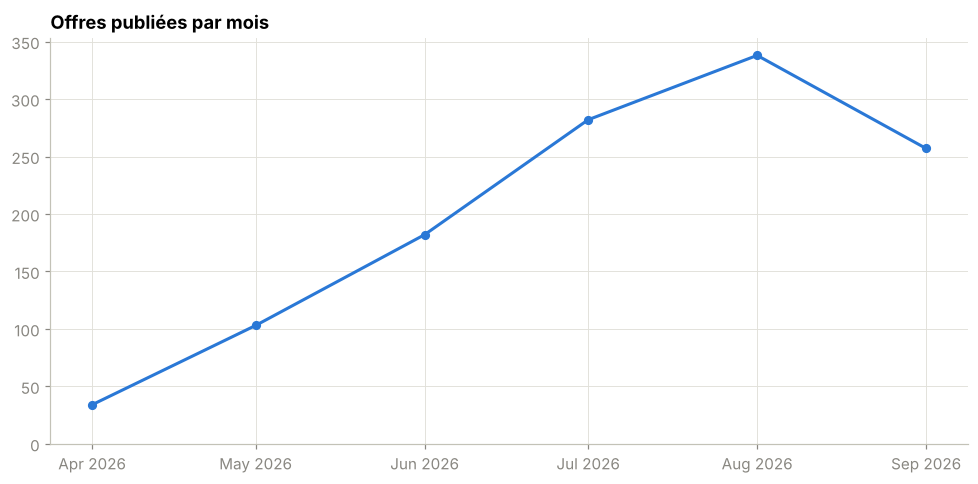

In [7]:
monthly = offers.dropna(subset=["published_month"]).groupby("published_month").size()
fig, ax = plt.subplots()
ax.plot(monthly.index, monthly.values, color=BLUE, linewidth=2, marker="o", markersize=5)
ax.set_title("Offres publiées par mois")
ax.set_ylim(bottom=0)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
plt.tight_layout()

## 3. Salaires

Périmètre : offres qui affichent un salaire, hors stage, alternance et TJM freelance. La médiane est préférée à la moyenne parce que la distribution est asymétrique.

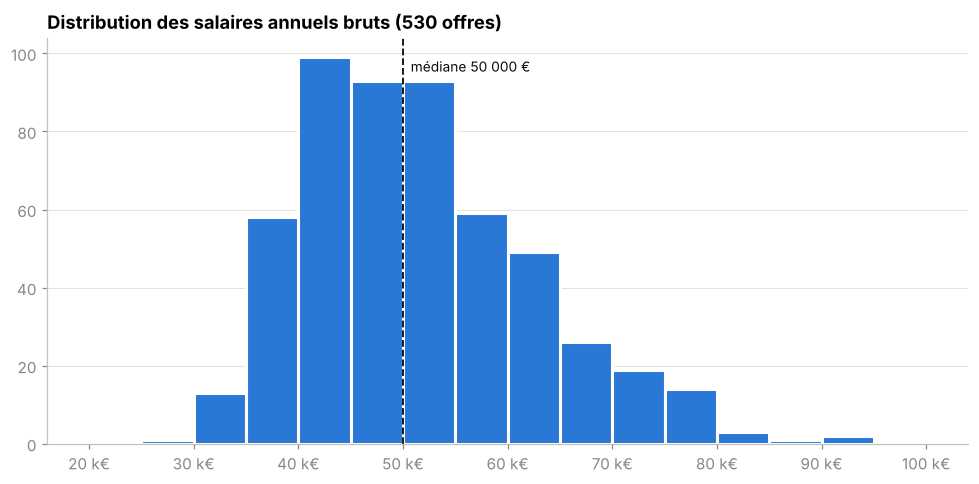

In [8]:
sal = offers.dropna(subset=["salary_mid"])
median = sal["salary_mid"].median()
fig, ax = plt.subplots()
ax.hist(sal["salary_mid"], bins=range(20000, 105000, 5000), color=BLUE, edgecolor="white", linewidth=2)
ax.axvline(median, color=INK, linewidth=1.2, linestyle="--")
ax.text(median, ax.get_ylim()[1] * 0.95, f"  médiane {median:,.0f} €".replace(",", " "), color=INK, fontsize=9, va="top")
ax.xaxis.set_major_formatter(eur)
ax.set_title(f"Distribution des salaires annuels bruts ({len(sal)} offres)")
ax.grid(axis="x", visible=False)
plt.tight_layout()

Médiane masquée sous 5 offres ; entre 5 et 10, elle reste fragile.


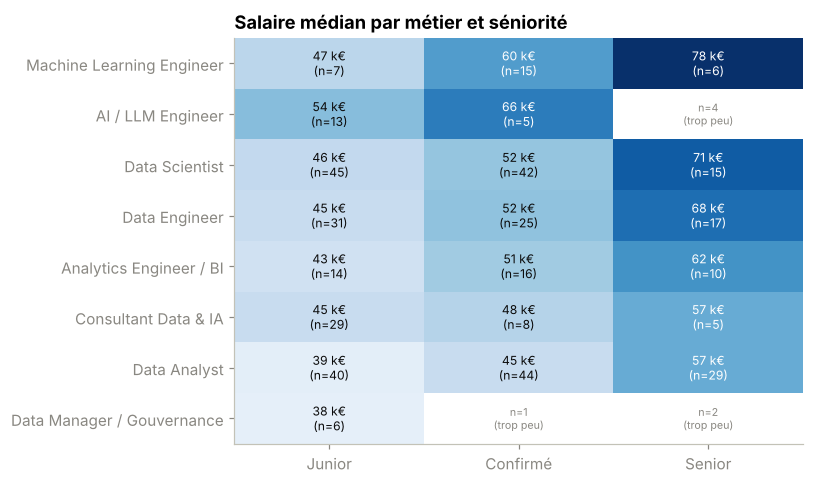

In [9]:
order = ["Junior", "Confirmé", "Senior"]
pivot = sal[sal["seniority"].isin(order)].pivot_table(index="role_family", columns="seniority",
                                                       values="salary_mid", aggfunc="median")[order]
n = sal[sal["seniority"].isin(order)].pivot_table(index="role_family", columns="seniority",
                                                  values="salary_mid", aggfunc="size")[order]
pivot = pivot.where(n >= 5)            # médiane non affichée sous 5 offres
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
im = ax.imshow(pivot.values, cmap=SEQ, aspect="auto", vmin=pivot.min().min() * 0.9)
ax.set_xticks(range(len(order)), order); ax.set_yticks(range(len(pivot)), pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v, k = pivot.iat[i, j], n.loc[pivot.index[i]].iat[j]
        if pd.isna(v):
            ax.text(j, i, f"n={0 if pd.isna(k) else int(k)}\n(trop peu)", ha="center", va="center", fontsize=7, color=MUTED)
        else:
            light = v > pivot.stack().quantile(0.6)
            ax.text(j, i, f"{v/1000:.0f} k€\n(n={int(k)})", ha="center", va="center", fontsize=8,
                    color="white" if light else INK)
ax.grid(False)
ax.set_title("Salaire médian par métier et séniorité")
plt.tight_layout()
print("Médiane masquée sous 5 offres ; entre 5 et 10, elle reste fragile.")

## 4. Compétences et technologies

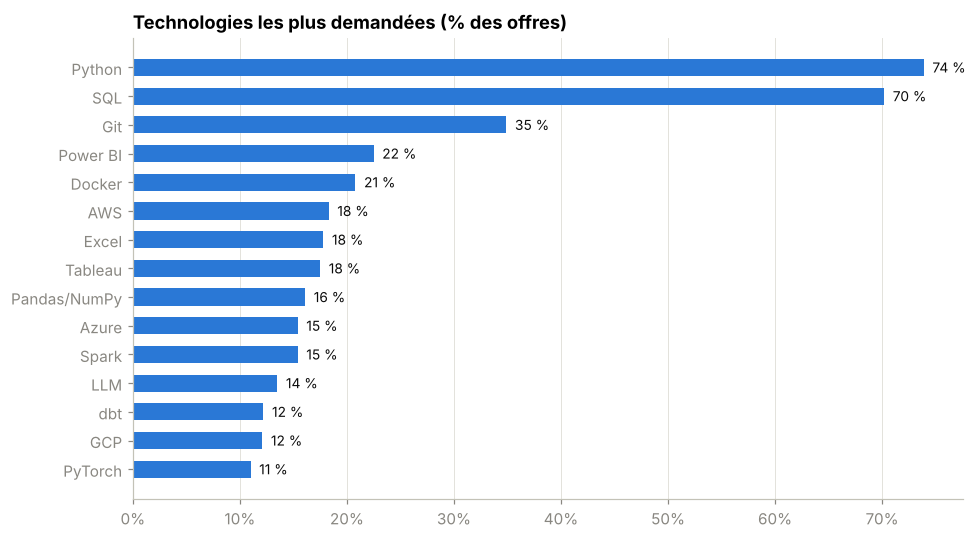

In [10]:
tech = (skills_by_role[(skills_by_role["metier"] == "Tous métiers") & (skills_by_role["type_competence"] == "Technologie")]
        .nlargest(15, "part_offres_pct").sort_values("part_offres_pct"))
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(tech["competence"], tech["part_offres_pct"], color=BLUE, height=0.6)
for y, v in enumerate(tech["part_offres_pct"]):
    ax.text(v + 0.8, y, f"{v:.0f} %", va="center", color=INK, fontsize=9)
ax.set_title("Technologies les plus demandées (% des offres)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="y", visible=False)
plt.tight_layout()

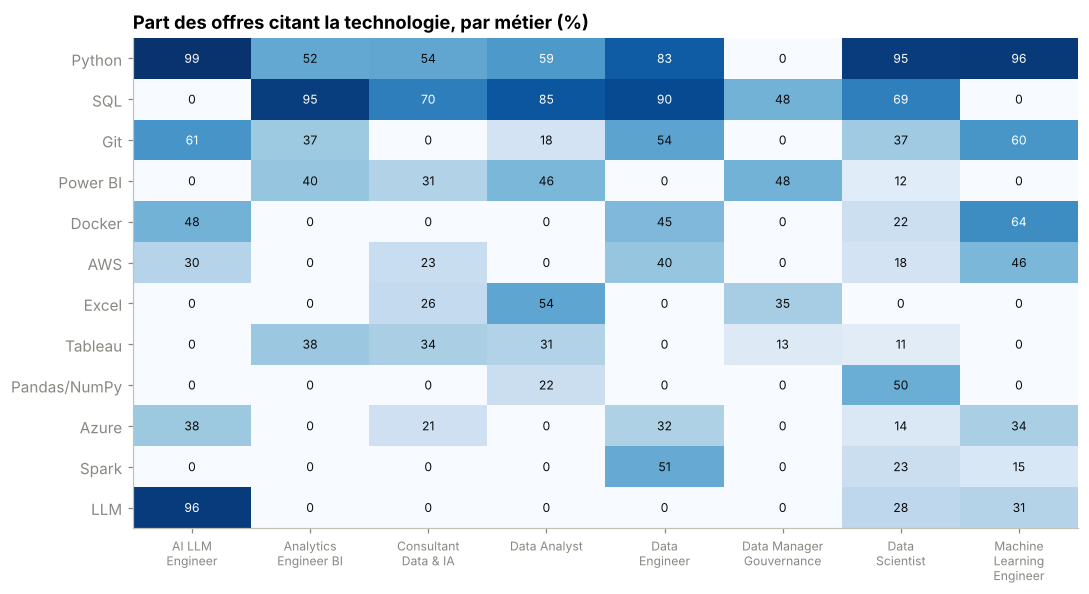

In [11]:
top_skills = tech["competence"].tolist()[::-1][:12]
heat = (skills_by_role[(skills_by_role["metier"] != "Tous métiers") & skills_by_role["competence"].isin(top_skills)]
        .pivot_table(index="competence", columns="metier", values="part_offres_pct", fill_value=0)
        .reindex(top_skills))
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.imshow(heat.values, cmap=SEQ, aspect="auto", vmin=0, vmax=100)
import textwrap
ax.set_xticks(range(heat.shape[1]), [textwrap.fill(c.replace(" / ", " "), 12) for c in heat.columns], fontsize=8)
ax.set_yticks(range(heat.shape[0]), heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.iat[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white" if v > 55 else INK)
ax.grid(False)
ax.set_title("Part des offres citant la technologie, par métier (%)")
plt.tight_layout()

## 5. Télétravail et séniorité

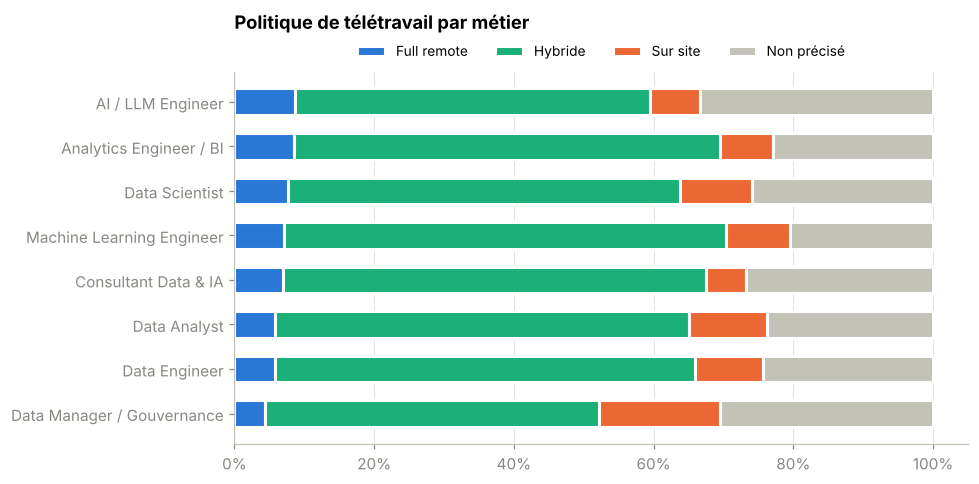

In [12]:
cats = ["Full remote", "Hybride", "Sur site", "Non précisé"]
colors = ["#2a78d6", "#1baf7a", "#eb6834", "#c3c2b7"]   # « Non précisé » en gris neutre
share = pd.crosstab(offers["role_family"], offers["remote_policy"], normalize="index").reindex(columns=cats, fill_value=0) * 100
share = share.sort_values(["Full remote", "Hybride"])
fig, ax = plt.subplots(figsize=(9, 4.5))
left = pd.Series(0.0, index=share.index)
for cat, col in zip(cats, colors):
    ax.barh(share.index, share[cat], left=left, color=col, label=cat, height=0.6, edgecolor="white", linewidth=2)
    left += share[cat]
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(ncol=4, loc="lower center", bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=9)
ax.set_title("Politique de télétravail par métier", pad=28)
ax.grid(axis="y", visible=False)
plt.tight_layout()

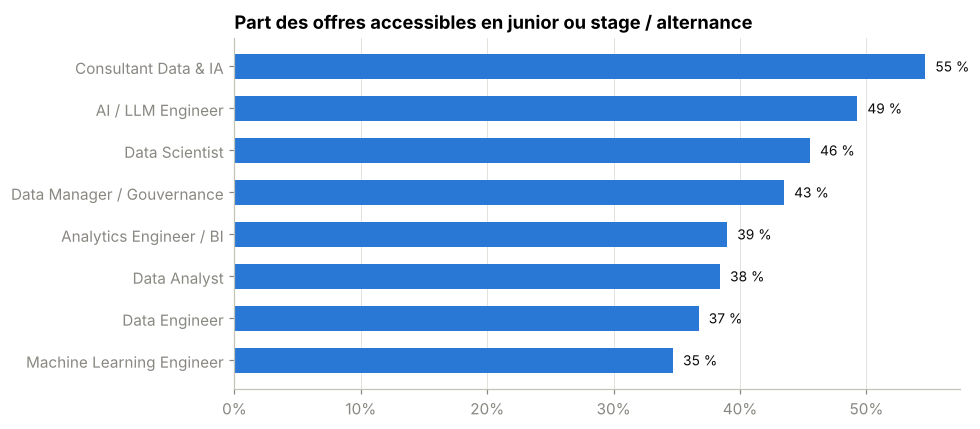

In [13]:
junior = (offers.assign(j=offers["seniority"].isin(["Junior", "Stage / Alternance"]))
          .groupby("role_family")["j"].mean().mul(100).sort_values())
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(junior.index, junior.values, color=BLUE, height=0.6)
for y, v in enumerate(junior.values):
    ax.text(v + 0.8, y, f"{v:.0f} %", va="center", color=INK, fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Part des offres accessibles en junior ou stage / alternance")
ax.grid(axis="y", visible=False)
plt.tight_layout()

## 6. À retenir

À rédiger **après la collecte réelle**, en 4 ou 5 phrases, à partir des graphiques ci-dessus et de `reports/insights.md` : le métier qui recrute le plus, le socle de compétences commun, ce qui distingue chaque métier, les salaires médians par séniorité, la place du télétravail. Ces phrases serviront aussi de légendes pour la Story Tableau.